In [2]:
import pandas as pd
import glob
import os

In [3]:
path = r"D:\phase_1_project\data_cleaning\processed\grid_hour"

all_files = glob.glob(os.path.join(path, "*.csv"))

df_list = [pd.read_csv(file) for file in all_files]

df = pd.concat(df_list, ignore_index=True)

print(df.head())

    timestamp  grid_id  sms_in  sms_out  call_in  call_out  internet  \
0  2013-11-01        1  2.0843   1.1047   0.5919    0.4293   57.7990   
1  2013-11-01        2  2.0915   1.0880   0.6020    0.4382   57.9149   
2  2013-11-01        3  2.0992   1.0701   0.6128    0.4476   58.0382   
3  2013-11-01        4  2.0633   1.1533   0.5627    0.4036   57.4634   
4  2013-11-01        5  1.8708   1.0439   0.5110    0.3740   52.1714   

         date  hour  day_of_week  total_sms  total_calls  total_activity  
0  2013-11-01     0            4     3.1890       1.0212         62.0092  
1  2013-11-01     0            4     3.1795       1.0402         62.1346  
2  2013-11-01     0            4     3.1693       1.0604         62.2679  
3  2013-11-01     0            4     3.2166       0.9663         61.6463  
4  2013-11-01     0            4     2.9147       0.8850         55.9711  


In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format = "mixed")

In [5]:
# 1. Drop the country_code column entirely
# df = df.drop(columns=['country_code'])

# # 2. Group by timestamp and grid_id
# df_grouped = df.groupby(['timestamp', 'grid_id']).agg({
#     'sms_in': 'sum',
#     'sms_out': 'sum',
#     'call_in': 'sum',
#     'call_out': 'sum',
#     'internet': 'sum',
#     'date': 'first',         # Keeps the date feature
#     'hour': 'first',         # Keeps the hour feature
#     'day_of_week': 'first'   # Keeps the day of week feature
# }).reset_index()

# # Check the new structure
# print(df_grouped.head())

In [6]:
len(df)

1679994

In [7]:
df.dtypes

timestamp         datetime64[us]
grid_id                    int64
sms_in                   float64
sms_out                  float64
call_in                  float64
call_out                 float64
internet                 float64
date                         str
hour                       int64
day_of_week                int64
total_sms                float64
total_calls              float64
total_activity           float64
dtype: object

In [8]:
df.groupby(["hour", "day_of_week"]).nunique()

timestamp  grid_id  sms_in  sms_out  call_in  call_out  \
hour day_of_week                                                           
0    0                    1    10000    8342     8154     7059      7591   
     1                    1    10000    8426     8146     7181      7582   
     2                    1    10000    8392     8168     7230      7724   
     3                    1    10000    8374     8064     7191      7632   
     4                    1    10000    8602     8309     7990      8228   
...                     ...      ...     ...      ...      ...       ...   
23   2                    1    10000    8728     8447     8114      8371   
     3                    1    10000    8699     8430     8070      8368   
     4                    1    10000    8699     8423     8004      8350   
     5                    1    10000    8766     8527     8144      8485   
     6                    1    10000    8702     8415     7985      8243   

                  internet  date  total_sms  total_calls  total_activity  
hour day_of_week                                                          
0    0                8845     1       8610         8184            8974  
     1                8921     1       8618         8173            8992  
     2                8831     1       8590         8262            8956  
     3                8836     1       8582         8209            8893  
     4                8902     1       8715         8594            8990  
...                    ...   ...        ...          ...             ...  
23   2                8865     1       8795         8660            8995  
     3                8909     1       8778         8670            9010  
     4                8897     1       8786         8622            9005  
     5                8866     1       8848         8712            9030  
     6                8871     1       8771         8558            8994  

[168 rows x 11 columns]

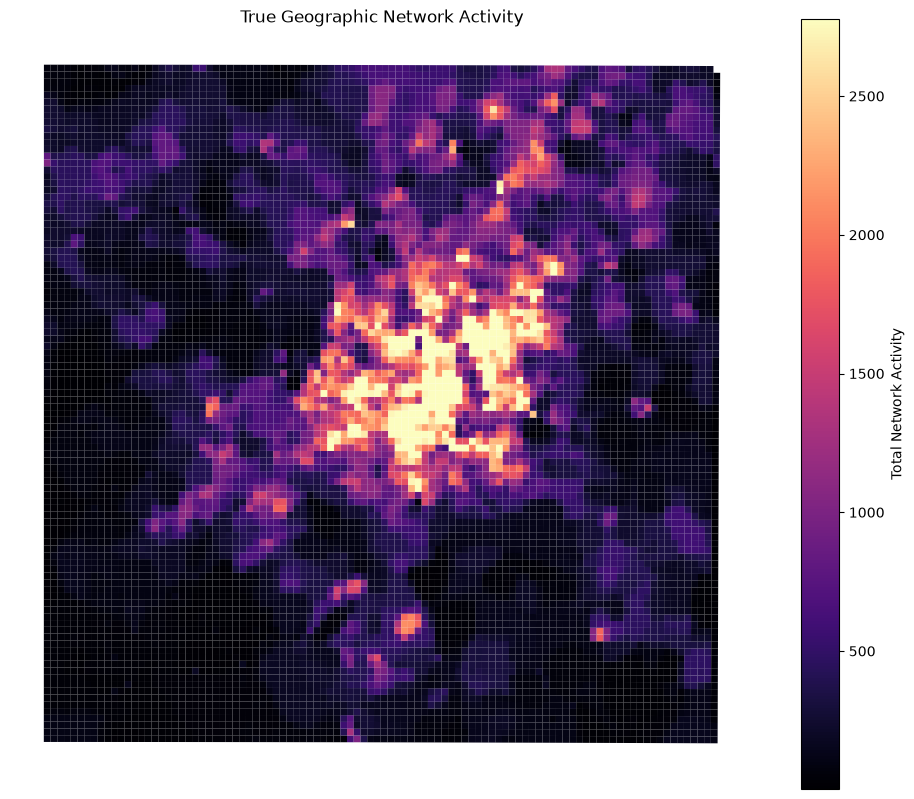

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt

grid_geo = gpd.read_file(r"D:\phase_1_project\data_set\grid\milano-grid.geojson")
grid_geo['grid_id'] = grid_geo['cellId'].astype(int) + 1
# grid_geo["id"] = grid_geo["id"].astype(int) + 1
time_slice = df[(df['day_of_week'] == 4) & (df['hour'] == 18)].copy()
map_df = grid_geo.merge(time_slice,on='grid_id')
vmax_cutoff = map_df['total_activity'].quantile(0.98)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

map_df.plot(column='total_activity', 
            cmap='magma', 
            linewidth=0,
            vmax=vmax_cutoff,      # Set to 0 (This is the speed fix!)
            edgecolor=None,        # Remove the border calculations
            legend=True, 
            legend_kwds={'label': "Total Network Activity"},
            ax=ax)

plt.title('True Geographic Network Activity')
ax.set_axis_off() 
plt.show()

In [10]:
import numpy as np

# 0. Guarantee strict chronological sorting (Critical for rolling windows)
df = df.sort_values(by=['timestamp'])

# 1. Cyclical Time Encoding (The Rhythm)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# 2. Service Divergence Ratios (Avoid division by zero using np.where)
df['data_to_voice_ratio'] = np.where(
    (df['call_in'] + df['call_out']) > 0, 
    df['internet'] / (df['call_in'] + df['call_out']), 
    0
)

# 3. Trailing Window Features (Ending at time 't')
# We group by grid_id so the rolling windows do not bleed across different grids
grouped_activity = df.groupby('grid_id')['total_activity']

# avg_activity: Mean over the last 24 hours
df['avg_activity'] = grouped_activity.transform(
    lambda x: x.rolling(24, min_periods=1).mean().shift(1)
)

# active_hours: Count of hours > 0 in the last 24 hours
df['active_hours'] = grouped_activity.transform(
    lambda x: (x > 0).rolling(24, min_periods=1).sum().shift(1)
)

# peak_ratio: Max / Mean over the last 24 hours
df['peak_ratio'] = grouped_activity.transform(
    lambda x: (x.rolling(24, min_periods=1).max() / 
               x.rolling(24, min_periods=1).mean()).shift(1)
)

# variability: Coefficient of Variation (Std / Mean)
df['variability'] = grouped_activity.transform(
    lambda x: (x.rolling(24, min_periods=1).std() / 
               x.rolling(24, min_periods=1).mean()).shift(1)
)

# activity_growth: Current 24h avg divided by the previous 24h avg (shifted by 25)
# df['activity_growth'] = df['avg_activity'] / grouped_activity.transform(
#     lambda x: x.rolling(24, min_periods=1).mean().shift(25)
# )
recent_12h_avg = grouped_activity.transform(lambda x: x.rolling(12, min_periods=1).mean().shift(1))
past_12h_avg = grouped_activity.transform(lambda x: x.rolling(12, min_periods=1).mean().shift(13))
df['activity_growth'] = recent_12h_avg / past_12h_avg
# internet_share: Shifted by 1 to represent the share up to time 't'
df['internet_share'] = (df['internet'] / df['total_activity']).fillna(0)
df['internet_share_at_t'] = df.groupby('grid_id')['internet_share'].shift(1)

In [11]:
df.head(10)

,timestamp,grid_id,sms_in,sms_out,call_in,call_out,internet,date,hour,day_of_week,...,hour_sin,hour_cos,data_to_voice_ratio,avg_activity,active_hours,peak_ratio,variability,activity_growth,internet_share,internet_share_at_t
0,2013-11-01,1,2.0843,1.1047,0.5919,0.4293,57.7990,2013-11-01,0,4,...,0.0,1.0,56.599099,NaN,NaN,NaN,NaN,NaN,0.932104,NaN
6663,2013-11-01,6664,27.0867,35.0800,7.7794,13.2237,1220.3040,2013-11-01,0,4,...,0.0,1.0,58.101137,NaN,NaN,NaN,NaN,NaN,0.936194,NaN
6664,2013-11-01,6665,49.4625,42.0739,19.3577,16.6207,1630.8316,2013-11-01,0,4,...,0.0,1.0,45.328075,NaN,NaN,NaN,NaN,NaN,0.927480,NaN
6665,2013-11-01,6666,47.0144,18.6233,8.9826,11.3788,863.0839,2013-11-01,0,4,...,0.0,1.0,42.388240,NaN,NaN,NaN,NaN,NaN,0.909387,NaN
6666,2013-11-01,6667,38.2910,17.8733,9.7898,19.9454,1170.5288,2013-11-01,0,4,...,0.0,1.0,39.365089,NaN,NaN,NaN,NaN,NaN,0.931632,NaN
6667,2013-11-01,6668,27.2884,15.2415,11.9880,18.4827,1034.2710,2013-11-01,0,4,...,0.0,1.0,33.943132,NaN,NaN,NaN,NaN,NaN,0.934072,NaN
6668,2013-11-01,6669,19.9442,10.2755,14.0883,12.2895,724.0648,2013-11-01,0,4,...,0.0,1.0,27.449780,NaN,NaN,NaN,NaN,NaN,0.927501,NaN
6669,2013-11-01,6670,28.7232,14.6153,17.8994,15.4518,1053.0986,2013-11-01,0,4,...,0.0,1.0,31.576033,NaN,NaN,NaN,NaN,NaN,0.932120,NaN
6670,2013-11-01,6671,37.6766,19.7225,19.2116,18.4795,1945.0812,2013-11-01,0,4,...,0.0,1.0,51.605849,NaN,NaN,NaN,NaN,NaN,0.953391,NaN
6671,2013-11-01,6672,34.1491,16.3937,15.8140,18.8652,1843.9960,2013-11-01,0,4,...,0.0,1.0,53.172968,NaN,NaN,NaN,NaN,NaN,0.955826,NaN


In [12]:
df.dtypes

timestamp              datetime64[us]
grid_id                         int64
sms_in                        float64
sms_out                       float64
call_in                       float64
call_out                      float64
internet                      float64
date                              str
hour                            int64
day_of_week                     int64
total_sms                     float64
total_calls                   float64
total_activity                float64
hour_sin                      float64
hour_cos                      float64
data_to_voice_ratio           float64
avg_activity                  float64
active_hours                  float64
peak_ratio                    float64
variability                   float64
activity_growth               float64
internet_share                float64
internet_share_at_t           float64
dtype: object

In [13]:
import numpy as np
import pandas as pd

# 1. Ensure model_df is correctly mapped from your main dataframe
# (This includes our spatial coordinates and drops any remaining NaNs)
df['x'] = (df['grid_id'] - 1) % 100
df['y'] = (df['grid_id'] - 1) // 100
df['target_drop'] = (df['total_activity'].shift(-1) < (0.4 * df['avg_activity'])).astype(int)

safe_features = [
    'variability', 'hour', 'hour_sin', 'hour_cos', 
    'internet_share_at_t', 'activity_growth', 'peak_ratio', 
    'avg_activity', 'data_to_voice_ratio', 'active_hours',
    'day_of_week', 'x', 'y'
]

model_df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=safe_features + ['target_drop'])

# 2. Extract features and target
X_secure = model_df[safe_features]
y = model_df['target_drop']

print(f"model_df is locked in! Total clean samples: {len(model_df):,}")

model_df is locked in! Total clean samples: 1,549,994


In [14]:
df["target_drop"].value_counts()


target_drop
0    1466655
1     213339
Name: count, dtype: int64

In [15]:
import numpy as np
import pandas as pd
from scipy.stats import f_oneway

# 1. Automatically grab all numeric columns
numeric_cols = model_df.select_dtypes(include=[np.number]).columns.tolist()

# 2. Exclude identifiers, the target label, and any pure date columns
cols_to_exclude = ['target_drop']
features_to_test = [
    'variability', 'hour', 'hour_sin', 'hour_cos', 
    'internet_share_at_t', 'activity_growth', 'peak_ratio', 
    'avg_activity', 'data_to_voice_ratio', 'active_hours',
    'day_of_week', 'x', 'y'
]

# 3. Split the data into our two target groups
group_normal = model_df[model_df['target_drop'] == 0]
group_drop = model_df[model_df['target_drop'] == 1]

# 4. Loop through ALL features safely
results = []
for feature in features_to_test:
    # Safety Check: Skip features that have exactly the same value everywhere
    # (SciPy will throw an error or return NaN if there is zero variance)
    if model_df[feature].nunique() <= 1:
        continue
        
    f_stat, p_val = f_oneway(group_normal[feature], group_drop[feature])
    results.append({'Feature': feature, 'F_Score': f_stat, 'P_Value': p_val})

# 5. Format and sort the results
anova_all_results = pd.DataFrame(results)
anova_all_results = anova_all_results.sort_values(by='F_Score', ascending=False).reset_index(drop=True)

# Display the top 15 most significant features
print(anova_all_results)

                Feature        F_Score       P_Value
0   internet_share_at_t  101255.816407  0.000000e+00
1                  hour   94109.503625  0.000000e+00
2              hour_sin   82226.343080  0.000000e+00
3              hour_cos   54650.408585  0.000000e+00
4          avg_activity   25610.553619  0.000000e+00
5           variability   24290.995281  0.000000e+00
6                     x   11898.088989  0.000000e+00
7            peak_ratio    8424.015770  0.000000e+00
8          active_hours    4740.376780  0.000000e+00
9   data_to_voice_ratio     296.747818  1.708181e-66
10                    y     179.844153  5.269127e-41
11          day_of_week     143.740756  4.061984e-33
12      activity_growth      53.131823  3.120457e-13


In [16]:
len(df)

1679994

In [17]:
model_df["target_drop"].value_counts()

target_drop
0    1346402
1     203592
Name: count, dtype: int64

In [18]:
# model_df['x'] = (model_df['grid_id'] - 1) % 100
# model_df['y'] = (model_df['grid_id'] - 1) // 100

In [19]:
# The absolute strict list of columns allowed to be features (Ending at 't')
# safe_features = [
#     'variability', 'hour', 'hour_sin', 'hour_cos', 
#     'internet_share_at_t', 'activity_growth', 'peak_ratio', 
#     'avg_activity', 'data_to_voice_ratio', 'active_hours',
#     'day_of_week', 'x' , 'y'
# ]

# # Create the final, secure dataframe for ML training
# X_secure = model_df[safe_features]
# y = model_df['target_drop']

In [20]:
# X_secure.dtypes

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Chronological Split (e.g., First 80% of rows for train, last 20% for test)
# Since we sorted by timestamp earlier, we can safely split by index
split_idx = int(len(X_secure) * 0.80)

X_train, X_test = X_secure.iloc[:split_idx], X_secure.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training on {len(X_train)} samples...")
print(f"Testing on {len(X_test)} samples...")

# 2. Initialize the Model (Random Forest is a great baseline for this)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

# 3. Train the Model!
model.fit(X_train, y_train)

# 4. Predict and Evaluate on the strict future holdout set
predictions = model.predict(X_test)

print("\n--- Model Evaluation ---")
print(classification_report(y_test, predictions))

Training on 1239995 samples...
Testing on 309999 samples...

--- Model Evaluation ---
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    267376
           1       0.64      0.58      0.61     42623

    accuracy                           0.90    309999
   macro avg       0.78      0.76      0.77    309999
weighted avg       0.89      0.90      0.89    309999



In [22]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import classification_report
import time

# 1. Calculate the exact class imbalance ratio for the training set
# Formula: count(negative class) / count(positive class)
imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Calculated Imbalance Ratio: {imbalance_ratio:.2f}\n")

# 2. Initialize LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    n_jobs=-1
)

# 3. Initialize XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

# 4. Train and Evaluate LightGBM
print("--- Training LightGBM ---")
start_time = time.time()
lgb_model.fit(X_train, y_train)
print(f"Done in {(time.time() - start_time):.2f} seconds.")

lgb_preds = lgb_model.predict(X_test)
print(classification_report(y_test, lgb_preds))

# 5. Train and Evaluate XGBoost
print("\n--- Training XGBoost ---")
start_time = time.time()
xgb_model.fit(X_train, y_train)
print(f"Done in {(time.time() - start_time):.2f} seconds.")

xgb_preds = xgb_model.predict(X_test)
print(classification_report(y_test, xgb_preds))

Calculated Imbalance Ratio: 6.70

--- Training LightGBM ---
[LightGBM] [Info] Number of positive: 160969, number of negative: 1079026
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.125432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1812
[LightGBM] [Info] Number of data points in the train set: 1239995, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.129814 -> initscore=-1.902602
[LightGBM] [Info] Start training from score -1.902602
Done in 27.29 seconds.
              precision    recall  f1-score   support

           0       0.97      0.81      0.88    267376
           1       0.41      0.83      0.55     42623

    accuracy                           0.81    309999
   macro avg       0.69      0.82      0.71    309999
weighted avg       0.89      0.81      0.83    309999


--- Training XGBoost ---
Done in 31.58 seconds.
              precision    recall  f1-scor

In [23]:
print(classification_report(y_test, xgb_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9732    0.8424    0.9031    267376
           1     0.4636    0.8545    0.6011     42623

    accuracy                         0.8441    309999
   macro avg     0.7184    0.8485    0.7521    309999
weighted avg     0.9031    0.8441    0.8616    309999



In [24]:
import pandas as pd

# Extract feature importances from the clean XGBoost model
importances = pd.Series(xgb_model.feature_importances_, index=safe_features).sort_values(ascending=False)
print("--- Leakage-Free Feature Importances ---")
print(importances)

--- Leakage-Free Feature Importances ---
hour                   0.557497
avg_activity           0.074406
variability            0.056495
y                      0.051353
x                      0.047440
day_of_week            0.046778
hour_cos               0.041901
internet_share_at_t    0.030607
data_to_voice_ratio    0.029008
hour_sin               0.024290
activity_growth        0.017871
peak_ratio             0.012190
active_hours           0.010163
dtype: float32


In [25]:
importances_2 = pd.Series(lgb_model.feature_importances_, index=safe_features).sort_values(ascending=False)
print("--- Leakage Free lgb importances ---")
print(importances_2)

--- Leakage Free lgb importances ---
y                      1845
x                      1682
avg_activity            969
variability             423
hour                    245
internet_share_at_t     163
data_to_voice_ratio     136
peak_ratio              131
day_of_week             129
activity_growth         111
hour_cos                 91
hour_sin                 67
active_hours              8
dtype: int32


In [26]:
importances_3 = pd.Series(model.feature_importances_,index=safe_features).sort_values(ascending=False)
print(importances_3)

avg_activity           0.141860
y                      0.112638
x                      0.112558
internet_share_at_t    0.109695
variability            0.098255
data_to_voice_ratio    0.098251
hour                   0.081328
peak_ratio             0.079474
activity_growth        0.071062
hour_cos               0.035455
hour_sin               0.033664
day_of_week            0.022635
active_hours           0.003126
dtype: float64


In [27]:
model_df.head(5)

,timestamp,grid_id,sms_in,sms_out,call_in,call_out,internet,date,hour,day_of_week,...,avg_activity,active_hours,peak_ratio,variability,activity_growth,internet_share,internet_share_at_t,x,y,target_drop
136668,2013-11-01 13:00:00,6669,79.3528,29.5345,37.7684,51.8366,798.7428,2013-11-01,13,4,...,741.976992,13.0,1.649477,0.413481,0.946316,0.800957,0.815910,68,66,0
136663,2013-11-01 13:00:00,6664,105.9240,70.4169,47.5596,52.2958,1531.2243,2013-11-01,13,4,...,1290.919462,13.0,1.619099,0.365191,0.989566,0.847188,0.841259,63,66,0
136664,2013-11-01 13:00:00,6665,144.9221,86.5812,87.0022,89.3750,1589.5064,2013-11-01,13,4,...,1698.744962,13.0,1.683059,0.395208,0.963279,0.795793,0.838711,64,66,0
136665,2013-11-01 13:00:00,6666,67.1006,32.8471,38.8212,48.4978,840.2667,2013-11-01,13,4,...,859.341031,13.0,1.607579,0.389883,0.897564,0.817751,0.826974,65,66,0
136666,2013-11-01 13:00:00,6667,83.3032,32.1489,50.9579,72.8217,1307.8584,2013-11-01,13,4,...,1217.646446,13.0,1.682918,0.396514,0.966561,0.845367,0.851916,66,66,0


In [28]:
model_df.value_counts()
model_df.shape

model_df["target_drop"].value_counts()


target_drop
0    1346402
1     203592
Name: count, dtype: int64

In [29]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, classification_report
import lightgbm as lgb
import xgboost as xgb

print("Preparing features vectorically...")

# 1. Ensure data is sorted for clean shifting
df = df.sort_values(by=['timestamp']).reset_index(drop=True)

# A. Daily Seasonality Lag (Lag-24: Activity at the exact same hour yesterday)
df['activity_lag_24'] = df.groupby('grid_id')['total_activity'].shift(24)

# B. Spatial Coordinates
df['x'] = (df['grid_id'] - 1) % 100
df['y'] = (df['grid_id'] - 1) // 100

# C. Fast Vectorized Neighborhood Average using Pivot Table
# Pivot so rows are timestamps, columns are grid_ids (1 to 10,000), values are total_activity
activity_pivot = df.pivot(index='timestamp', columns='grid_id', values='total_activity')

# Compute neighbor sums/means vectorically by shifting the pivot columns
# (A grid at (x, y) has grid_id = y * 100 + x + 1)
neighbor_activity_list = []
timestamps = df['timestamp'].values
grid_ids = df['grid_id'].values
xs = df['x'].values
ys = df['y'].values

# Fast dictionary or numpy lookup from the pivot table
# Instead of iterating rows in pandas, we use numpy arrays for lightning speed
activity_matrix = activity_pivot.values
time_index_map = {t: i for i, t in enumerate(activity_pivot.index)}
grid_id_map = {g: j for j, g in enumerate(activity_pivot.columns)}

# Pre-calculate neighbor grid IDs for all 10,000 grids to avoid repeating logic
valid_neighbors_map = {}
for gid in range(1, 10001):
    gx = (gid - 1) % 100
    gy = (gid - 1) // 100
    neighbors = [
        (gy + dy) * 100 + (gx + dx) + 1 
        for dy in [-1, 0, 1] for dx in [-1, 0, 1] 
        if (dx != 0 or dy != 0) and (0 <= gx + dx < 100) and (0 <= gy + dy < 100)
    ]
    valid_neighbors_map[gid] = [grid_id_map[n] for n in neighbors if n in grid_id_map]

# Vectorized extraction using numpy indexing
print("Calculating spatial neighborhood averages...")
neighbor_avgs = np.empty(len(df))
for i in range(len(df)):
    t_idx = time_index_map[timestamps[i]]
    n_cols = valid_neighbors_map[grid_ids[i]]
    if n_cols:
        neighbor_avgs[i] = np.nanmean(activity_matrix[t_idx, n_cols])
    else:
        neighbor_avgs[i] = np.nan

df['neighbor_avg_activity'] = neighbor_avgs

# Update safe features
safe_features = [
    'variability', 'hour', 'hour_sin', 'hour_cos', 
    'internet_share_at_t', 'activity_growth', 'peak_ratio', 
    'avg_activity', 'data_to_voice_ratio', 'active_hours',
    'day_of_week', 'x', 'y', 'activity_lag_24', 'neighbor_avg_activity'
]

# Clean up NaNs and split chronologically
model_df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=safe_features + ['target_drop'])
model_df = model_df.sort_values(by='timestamp').reset_index(drop=True)

split_idx = int(len(model_df) * 0.80)
X_train = model_df.iloc[:split_idx][safe_features]
y_train = model_df.iloc[:split_idx]['target_drop']
X_test = model_df.iloc[split_idx:][safe_features]
y_test = model_df.iloc[split_idx:][['target_drop']]

# Train and Evaluate
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
train_scale_pos_weight = neg_count / pos_count

xgb_model = xgb.XGBClassifier(scale_pos_weight=train_scale_pos_weight, max_depth=6, n_estimators=150, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_probs)

optimal_threshold = thresholds[np.argmax(precisions >= 0.65)] if any(precisions >= 0.65) else 0.5
tuned_preds = (xgb_probs >= optimal_threshold).astype(int)

print("\n--- Optimized XGBoost Performance ---")
print(classification_report(y_test, tuned_preds, digits=4))

Preparing features vectorically...
Calculating spatial neighborhood averages...

--- Optimized XGBoost Performance ---
              precision    recall  f1-score   support

           0     0.9385    0.9423    0.9404    246392
           1     0.6500    0.6344    0.6421     41607

    accuracy                         0.8978    287999
   macro avg     0.7943    0.7883    0.7912    287999
weighted avg     0.8968    0.8978    0.8973    287999



In [30]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test,xgb_probs)

0.9226581152804603

In [31]:
model_df["target_drop"].value_counts()

target_drop
0    1243188
1     196806
Name: count, dtype: int64

In [35]:
import joblib

# 1. Create a deployment package dictionary
deployment_package = {
    'model': xgb_model,
    'features': safe_features,
    'optimal_threshold': optimal_threshold
}

# 2. Save the package to your disk
export_path = r"D:\phase_1_project\xgboost_drop_detector.pkl"
joblib.dump(deployment_package, export_path)

print(f"\n--- Model Successfully Exported ---")
print(f"Saved to: {export_path}")
print(f"Required Features: {len(safe_features)}")
print(f"Custom Decision Threshold locked in at: {optimal_threshold:.4f}")

# (Optional) You can also save just the raw XGBoost weights natively:
xgb_model.save_model(r"D:\phase_1_project\training_feature_engineering\xgboost_weights.json")


--- Model Successfully Exported ---
Saved to: D:\phase_1_project\xgboost_drop_detector.pkl
Required Features: 15
Custom Decision Threshold locked in at: 0.7389


In [33]:
import pandas as pd
from sqlalchemy import create_engine

# 1. Define your MySQL connection
USER = "root"          # Replace with your MySQL username
PASSWORD = "root"      # Replace with your MySQL password
HOST = "localhost"     # Usually localhost or 127.0.0.1
PORT = "3306"          # Default MySQL port
DB_NAME = "phase_1"    # Replace with your actual database name

# Create the MySQL engine
engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}")

# 2. Extract and format the FULL features from your model_df
# This now matches the exact 'safe_features' used by your XGBoost model
full_feature_columns = [
    'grid_id', 
    'timestamp',
    'variability', 
    'hour', 
    'hour_sin', 
    'hour_cos', 
    'internet_share_at_t', 
    'activity_growth', 
    'peak_ratio', 
    'avg_activity', 
    'data_to_voice_ratio', 
    'active_hours',
    'day_of_week', 
    'x', 
    'y', 
    'activity_lag_24', 
    'neighbor_avg_activity'
]

db_features = model_df[full_feature_columns].copy()

# Ensure the timestamp is a proper datetime object before pushing to MySQL
db_features['timestamp'] = pd.to_datetime(db_features['timestamp'])

# 3. Push to MySQL
print("Pushing full feature set to MySQL database...")
db_features.to_sql('grid_features', engine, if_exists='replace', index=False)
print("Done! The /features endpoint now has all model features.")

Pushing full feature set to MySQL database...
Done! The /features endpoint now has all model features.


In [34]:
# import pandas as pd
# from sqlalchemy import create_engine

# engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}")

# # 1. Load the JSON file
# alerts_df = pd.read_json(r"D:\phase_1_project\rule_based_anomaly_detection\processed\alerts\network_alerts.json") 

# # Ensure timestamps are actual datetime objects for MySQL
# alerts_df['timestamp'] = pd.to_datetime(alerts_df['timestamp'])

# # 2. Push to MySQL
# print("Pushing JSON alerts to MySQL...")
# alerts_df.to_sql('network_rule_alerts', engine, if_exists='replace', index=False)
# print("Done! Both /alerts and /hotspots endpoints are ready.")